## **MTN Nigeria Customer Churn Prediction Project**

**Objective**  
Transform the cleaned customer-level dataset into a high-quality, modeling-ready feature set that preserves the strongest signals identified in EDA while adding a small number of high-value, interpretable engineered features.

**Business Context**  
We want to identify customers at high risk of churning so MTN Nigeria can proactively offer targeted retention interventions (better data bundles, loyalty discounts, network quality improvements in high-churn regions, etc.) → directly protecting revenue in a highly competitive telecom market.

**Key EDA Takeaways Guiding Feature Engineering**  
- **Strongest predictors**: `Primary_Plan_Type` (Daily & 2-Day plans → much higher churn), `Usage_vs_Purchased_Ratio` (churners consume relatively more), `State` (strong geographic pattern: Yobe, Edo, Abuja (FCT), Abia highest)
- **Important but weaker**: `Customer_Tenure_Months`, `Total_Revenue` (LTV proxy), `Avg_Satisfaction_Rate`
- **High skew** in revenue, data usage, usage ratio → needs transformation
- **High multicollinearity** among volume-based features → we keep only the most interpretable representatives
- **Churn rate** ≈ 30% (moderate imbalance)

**Guiding Principles for this Notebook**  
- Minimal feature explosion → focus on quality over quantity  
- Preserve interpretability for business stakeholders  
- Transformations friendly to both tree-based models (Random Forest, XGBoost, LightGBM) and linear models  
- No data leakage (target-aware operations only in cross-validation later)

**Setup & Libraries Import**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder, StandardScaler
import category_encoders as ce
import joblib

**Load customer-level data**

In [2]:
df = pd.read_csv("C:\\Users\\KOLADE\\OneDrive\\Documents\\AkoladeDSJourney\\MTN-Nigeria-Customer-Churn\\data\\processed\\mtn_customer_level_churn.csv")

print(df.shape)
print(df["Churn"].value_counts(normalize=True).round(3)) # Expected ~30% churn

df.head(3)

(496, 23)
Churn
0    0.706
1    0.294
Name: proportion, dtype: float64


,Customer ID,Age,State,Gender,Device_Count,Active_Months,Total_Purchases,Avg_Unit_Price,Total_Revenue,Avg_Satisfaction_Rate,...,Total_Data_Usage_GB,Avg_GB_Purchased,Total_GB_Purchased,Primary_Plan_Type,Churn_Status,Reasons_for_Churn,Churn,Usage_vs_Purchased_Ratio,Revenue_per_Purchase,Tenure_Bucket
0,CUST0001,27,Kwara,Male,1,1,19,35000.000000,665000,2.0,...,44.48,165.000000,3135.0,Monthly,Yes,Relocation,1,0.014188,35000.00000,0-6
1,CUST0002,16,Abuja (FCT),Female,1,1,12,5500.000000,66000,2.0,...,19.79,12.500000,150.0,Monthly,Yes,Better Offers from Competitors,1,0.131933,5500.00000,13-24
2,CUST0003,21,Sokoto,Male,3,1,31,9833.333333,299000,1.0,...,283.03,60.333333,1658.0,Monthly,No,NaN,0,0.170706,9645.16129,37+


### Select Core Modeling Features (from EDA)

In [3]:
core_features = [
    "Customer_Tenure_Months",
    "Total_Revenue",
    "Avg_Satisfaction_Rate",
    "Primary_Review",
    "Primary_Plan_Type",
    "State",
    "Usage_vs_Purchased_Ratio",
    "Avg_Data_Usage_GB",
    "Churn"
]

df_model = df[core_features].copy()
print(df_model.shape)
print(df_model["Churn"].value_counts(normalize=True).round(3)) # Expected ~30% churn

df_model.head(3)

(496, 9)
Churn
0    0.706
1    0.294
Name: proportion, dtype: float64


,Customer_Tenure_Months,Total_Revenue,Avg_Satisfaction_Rate,Primary_Review,Primary_Plan_Type,State,Usage_vs_Purchased_Ratio,Avg_Data_Usage_GB,Churn
0,2,665000,2.0,Fair,Monthly,Kwara,0.014188,44.480000,1
1,22,66000,2.0,Fair,Monthly,Abuja (FCT),0.131933,19.790000,1
2,60,299000,1.0,Poor,Monthly,Sokoto,0.170706,94.343333,0


### Handle Skew & Outliers – Log Transformations
Revenue, data usage, and usage ratio are right-skewed → log-transform helps.

In [4]:
for col in ["Total_Revenue", "Usage_vs_Purchased_Ratio"]:
    df_model[f"log_{col}"] = np.log1p(df_model[col].clip(lower=0))

from scipy.stats.mstats import winsorize
df_model["winsor_Usage_Ratio"] = winsorize(df_model["Usage_vs_Purchased_Ratio"], limits=[0.01, 0.01])
# We keep both original + log/winsorized versions → trees can choose what works best

df_model.head(3)

,Customer_Tenure_Months,Total_Revenue,Avg_Satisfaction_Rate,Primary_Review,Primary_Plan_Type,State,Usage_vs_Purchased_Ratio,Avg_Data_Usage_GB,Churn,log_Total_Revenue,log_Usage_vs_Purchased_Ratio,winsor_Usage_Ratio
0,2,665000,2.0,Fair,Monthly,Kwara,0.014188,44.480000,1,13.407544,0.014088,0.014188
1,22,66000,2.0,Fair,Monthly,Abuja (FCT),0.131933,19.790000,1,11.097425,0.123927,0.131933
2,60,299000,1.0,Poor,Monthly,Sokoto,0.170706,94.343333,0,12.608202,0.157607,0.170706



Variable: Total_Revenue
Missing: 0.00%


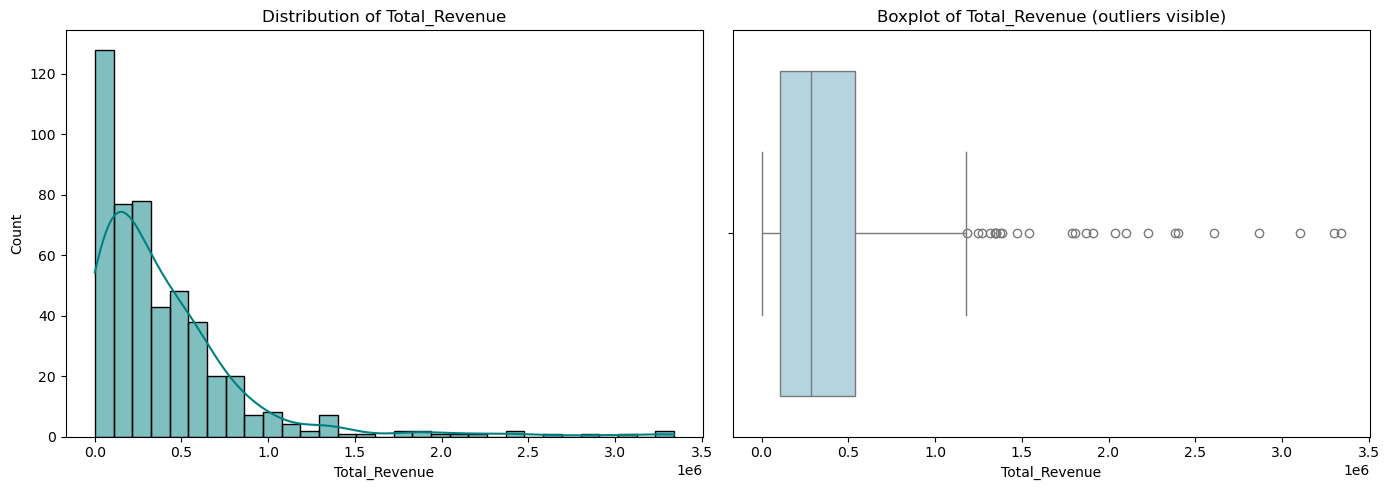


Variable: log_Total_Revenue
Missing: 0.00%


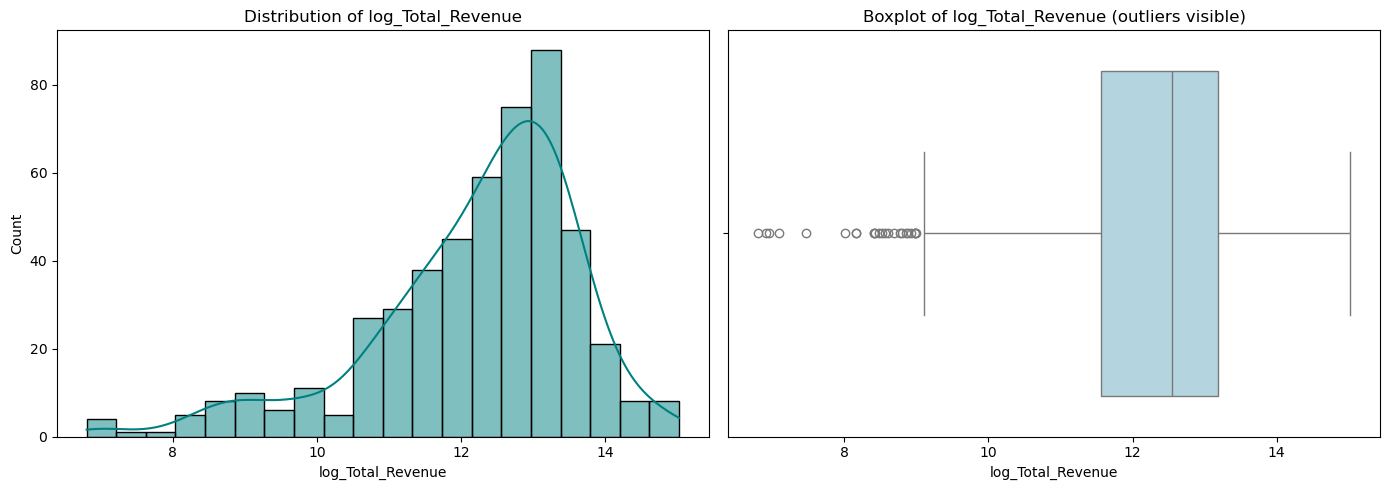


Variable: Usage_vs_Purchased_Ratio
Missing: 0.00%


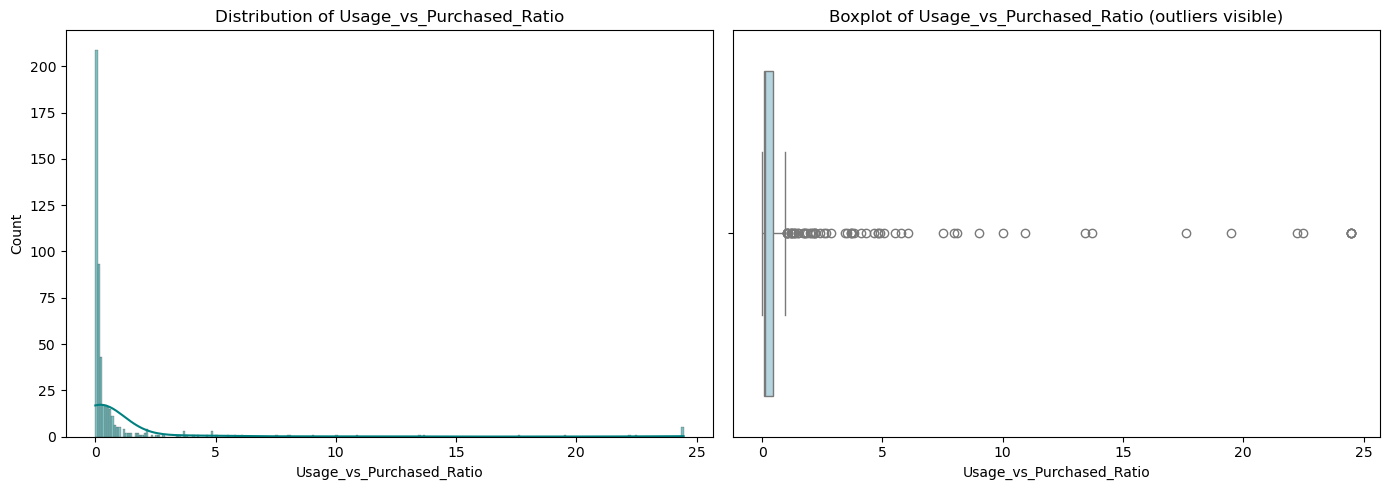


Variable: log_Usage_vs_Purchased_Ratio
Missing: 0.00%


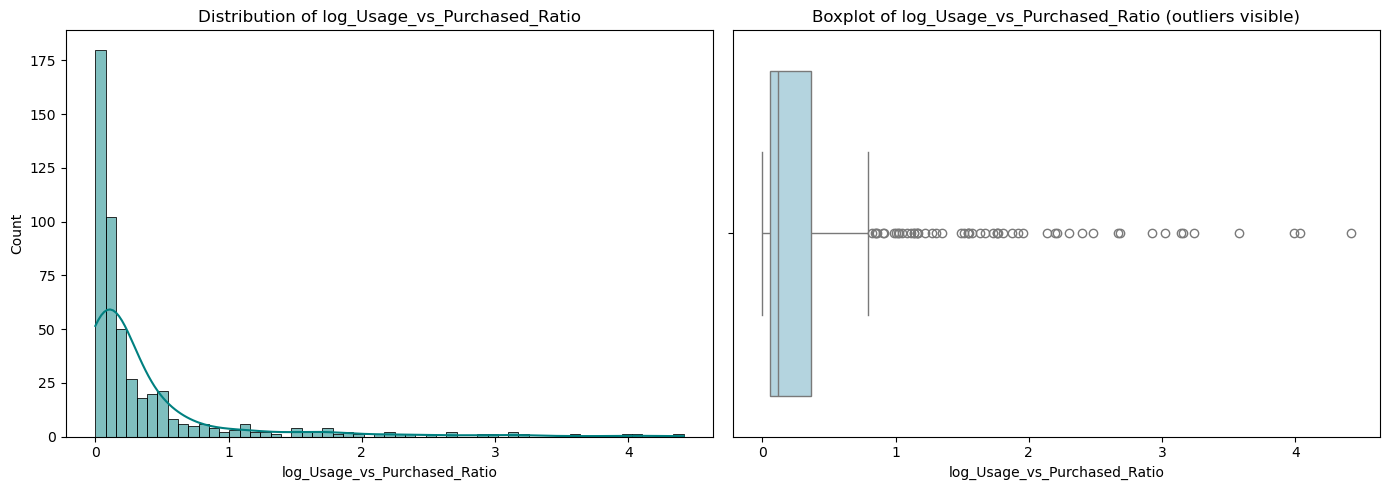


Variable: winsor_Usage_Ratio
Missing: 0.00%


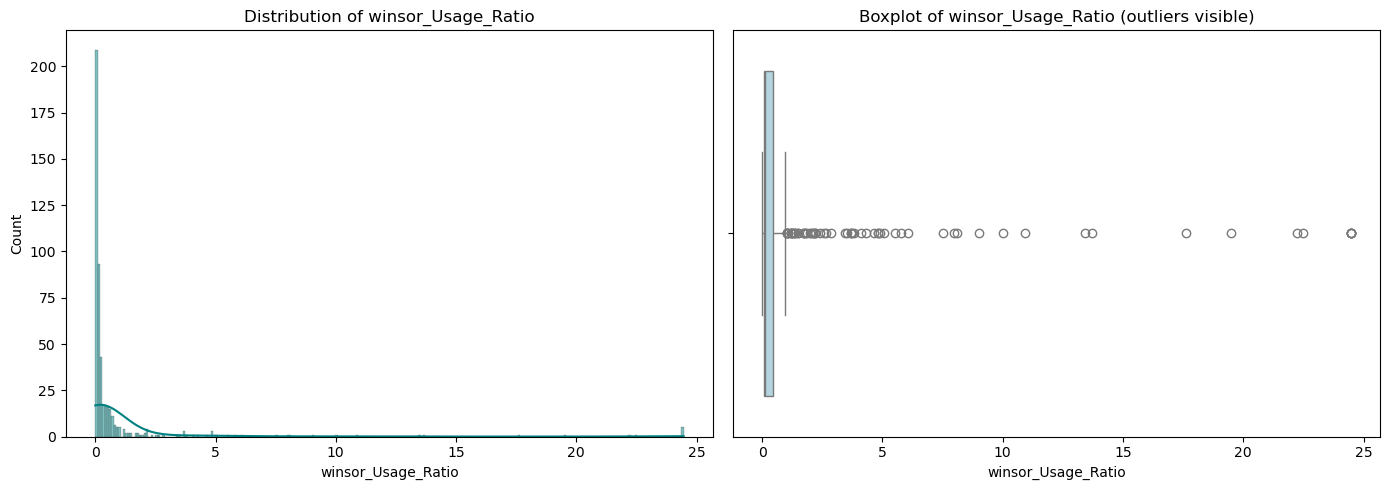

In [5]:
for col in ["Total_Revenue", "log_Total_Revenue", "Usage_vs_Purchased_Ratio", "log_Usage_vs_Purchased_Ratio", "winsor_Usage_Ratio"]:
    print(f"\n{'='*50}\nVariable: {col}")
    # Missing check
    miss = df_model[col].isna().mean() * 100
    print(f"Missing: {miss:.2f}%")
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram / KDE
    sns.histplot(data=df_model, x=col, kde=True, ax=axes[0], color='teal')
    axes[0].set_title(f'Distribution of {col}')
    
    # Boxplot (outliers)
    sns.boxplot(data=df_model, x=col, ax=axes[1], color='lightblue')
    axes[1].set_title(f'Boxplot of {col} (outliers visible)')
    
    plt.tight_layout()
    plt.show()

### Categorical Encoding Strategy

- Primary_Plan_Type → one-hot (low cardinality, very strong signal)
- State → group into churn-risk buckets and also group into region + one-hot (interpretability + dimensionality control) 
- Primary_Review → one-hot (small cardinality)

In [6]:
df_model.groupby("State")["Churn"].mean().sort_values(ascending=False).round(3)

State
Adamawa        0.636
Imo            0.562
Kebbi          0.500
Benue          0.438
Niger          0.417
Yobe           0.412
Anambra        0.400
Akwa Ibom      0.400
Edo            0.375
Kwara          0.364
Abuja (FCT)    0.353
Abia           0.333
Nasarawa       0.333
Lagos          0.333
Jigawa         0.308
Kano           0.300
Oyo            0.294
Zamfara        0.267
Ekiti          0.250
Katsina        0.250
Kogi           0.250
Gombe          0.250
Enugu          0.235
Taraba         0.231
Cross River    0.214
Sokoto         0.214
Delta          0.200
Rivers         0.200
Bayelsa        0.200
Plateau        0.154
Bauchi         0.150
Osun           0.150
Kaduna         0.125
Borno          0.111
Ondo           0.111
Name: Churn, dtype: float64

Categorize states based on their churn rate

| Churn Rate  | Category     |
| ----------- | ------------ |
| ≥ 0.50      | High Churn   |
| 0.30 – 0.49 | Medium Churn |
| < 0.30      | Low Churn    |


In [7]:
state_churn_rate = df_model.groupby("State")["Churn"].mean()

df_model["State_Group"] = df_model["State"].map(state_churn_rate).apply(
    lambda x: "High_Churn_State" if x >= 0.5 
    else "Medium_Churn_State" if x >= 0.3 
    else "Low_Churn_State"
)

Group States by Region

| Region        | States                                                |
| ------------- | ----------------------------------------------------- |
| North West    | Kano, Katsina, Kaduna, Kebbi, Sokoto, Zamfara, Jigawa |
| North East    | Adamawa, Bauchi, Borno, Gombe, Taraba, Yobe           |
| North Central | Benue, Kogi, Kwara, Nasarawa, Niger, Plateau, Abuja   |
| South West    | Lagos, Ogun, Oyo, Osun, Ondo, Ekiti                   |
| South East    | Abia, Anambra, Ebonyi, Enugu, Imo                     |
| South South   | Akwa Ibom, Bayelsa, Cross River, Delta, Edo, Rivers   |


In [8]:
region_map = {
    'Lagos':'South West', 'Oyo':'South West', 'Osun':'South West',
    'Ondo':'South West', 'Ekiti':'South West',

    'Imo':'South East','Abia':'South East','Anambra':'South East','Enugu':'South East',

    'Rivers':'South South','Delta':'South South','Edo':'South South',
    'Akwa Ibom':'South South','Bayelsa':'South South','Cross River':'South South',

    'Kano':'North West','Kaduna':'North West','Katsina':'North West',
    'Sokoto':'North West','Zamfara':'North West','Kebbi':'North West','Jigawa':'North West',

    'Adamawa':'North East','Bauchi':'North East','Borno':'North East',
    'Gombe':'North East','Taraba':'North East','Yobe':'North East',

    'Benue':'North Central','Kogi':'North Central','Kwara':'North Central',
    'Nasarawa':'North Central','Niger':'North Central','Plateau':'North Central',
    'Abuja (FCT)':'North Central'
}

df_model['Region'] = df_model['State'].map(region_map)

In [9]:
df_model.head()

,Customer_Tenure_Months,Total_Revenue,Avg_Satisfaction_Rate,Primary_Review,Primary_Plan_Type,State,Usage_vs_Purchased_Ratio,Avg_Data_Usage_GB,Churn,log_Total_Revenue,log_Usage_vs_Purchased_Ratio,winsor_Usage_Ratio,State_Group,Region
0,2,665000,2.0,Fair,Monthly,Kwara,0.014188,44.480000,1,13.407544,0.014088,0.014188,Medium_Churn_State,North Central
1,22,66000,2.0,Fair,Monthly,Abuja (FCT),0.131933,19.790000,1,11.097425,0.123927,0.131933,Medium_Churn_State,North Central
2,60,299000,1.0,Poor,Monthly,Sokoto,0.170706,94.343333,0,12.608202,0.157607,0.170706,Low_Churn_State,North West
3,14,40500,1.0,Poor,Monthly,Gombe,1.030222,92.720000,0,10.609082,0.708145,1.030222,Low_Churn_State,North East
4,53,144000,3.0,Good,Monthly,Oyo,0.107300,42.920000,0,11.877576,0.101925,0.107300,Low_Churn_State,South West


In [10]:
cat_cols_to_encode = ["Primary_Plan_Type", "State_Group", "Primary_Review", "Region"]

encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

encoded_array = encoder.fit_transform(df_model[cat_cols_to_encode])

encoded_cats = pd.DataFrame(
    encoded_array,
    columns=encoder.get_feature_names_out(cat_cols_to_encode),
    index=df_model.index
)

# Combine encoded columns with dataset
df_final = pd.concat(
    [
        df_model.drop(columns=cat_cols_to_encode + ["State"]),
        encoded_cats
    ],
    axis=1
)

In [11]:
df_final

,Customer_Tenure_Months,Total_Revenue,Avg_Satisfaction_Rate,Usage_vs_Purchased_Ratio,Avg_Data_Usage_GB,Churn,log_Total_Revenue,log_Usage_vs_Purchased_Ratio,winsor_Usage_Ratio,Primary_Plan_Type_2-Day,...,Primary_Review_Fair,Primary_Review_Good,Primary_Review_Poor,Primary_Review_Very Good,Region_North Central,Region_North East,Region_North West,Region_South East,Region_South South,Region_South West
0,2,665000,2.0,0.014188,44.480000,1,13.407544,0.014088,0.014188,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,22,66000,2.0,0.131933,19.790000,1,11.097425,0.123927,0.131933,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,60,299000,1.0,0.170706,94.343333,0,12.608202,0.157607,0.170706,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
3,14,40500,1.0,1.030222,92.720000,0,10.609082,0.708145,1.030222,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,53,144000,3.0,0.107300,42.920000,0,11.877576,0.101925,0.107300,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,41,65700,2.0,1.680270,124.340000,1,11.092869,0.985918,1.680270,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
492,19,788000,5.0,0.059590,73.096667,0,13.577255,0.057882,0.059590,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
493,42,123000,3.0,0.045232,14.135000,0,11.719948,0.044239,0.045232,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
494,20,90000,2.0,0.513767,154.130000,0,11.407576,0.414601,0.513767,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### Domain-Meaningful Engineered Features
Small set of business-aligned interactions/flags.

In [12]:
# Flag: Short tenure + unusually high consumption ratio → likely price-sensitive churner
df_final["short_tenure_high_usage_flag"] = (
    (df_final["Customer_Tenure_Months"] <= 6) &
    (df_final["Usage_vs_Purchased_Ratio"] >= 1.5)
).astype(int)

# Flag: High lifetime value customer (protect these!)
p75 = df_final["Total_Revenue"].quantile(0.75)
df_final["high_value_customer"] = (df_final["Total_Revenue"] >= p75).astype(int)

# Flag: Short-cycle plan user (strongest categorical signal)
df_final["short_cycle_plan_flag"] = (
    df_final.get("Primary_Plan_Type_Daily Plan", pd.Series(0, index=df_final.index)) +
    df_final.get("Primary_Plan_Type_2-Day Plan", pd.Series(0, index=df_final.index))
).clip(upper=1).astype(int)

In [13]:
df_final

,Customer_Tenure_Months,Total_Revenue,Avg_Satisfaction_Rate,Usage_vs_Purchased_Ratio,Avg_Data_Usage_GB,Churn,log_Total_Revenue,log_Usage_vs_Purchased_Ratio,winsor_Usage_Ratio,Primary_Plan_Type_2-Day,...,Primary_Review_Very Good,Region_North Central,Region_North East,Region_North West,Region_South East,Region_South South,Region_South West,short_tenure_high_usage_flag,high_value_customer,short_cycle_plan_flag
0,2,665000,2.0,0.014188,44.480000,1,13.407544,0.014088,0.014188,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1,0
1,22,66000,2.0,0.131933,19.790000,1,11.097425,0.123927,0.131933,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,60,299000,1.0,0.170706,94.343333,0,12.608202,0.157607,0.170706,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0
3,14,40500,1.0,1.030222,92.720000,0,10.609082,0.708145,1.030222,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,0
4,53,144000,3.0,0.107300,42.920000,0,11.877576,0.101925,0.107300,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,41,65700,2.0,1.680270,124.340000,1,11.092869,0.985918,1.680270,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
492,19,788000,5.0,0.059590,73.096667,0,13.577255,0.057882,0.059590,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0
493,42,123000,3.0,0.045232,14.135000,0,11.719948,0.044239,0.045232,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
494,20,90000,2.0,0.513767,154.130000,0,11.407576,0.414601,0.513767,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0


### Standard Scaling (for linear models / distance-based algos)

In [14]:
df_final.columns

Index(['Customer_Tenure_Months', 'Total_Revenue', 'Avg_Satisfaction_Rate',
       'Usage_vs_Purchased_Ratio', 'Avg_Data_Usage_GB', 'Churn',
       'log_Total_Revenue', 'log_Usage_vs_Purchased_Ratio',
       'winsor_Usage_Ratio', 'Primary_Plan_Type_2-Day',
       'Primary_Plan_Type_3-Month', 'Primary_Plan_Type_Daily',
       'Primary_Plan_Type_Monthly', 'Primary_Plan_Type_Yearly',
       'State_Group_High_Churn_State', 'State_Group_Low_Churn_State',
       'State_Group_Medium_Churn_State', 'Primary_Review_Excellent',
       'Primary_Review_Fair', 'Primary_Review_Good', 'Primary_Review_Poor',
       'Primary_Review_Very Good', 'Region_North Central', 'Region_North East',
       'Region_North West', 'Region_South East', 'Region_South South',
       'Region_South West', 'short_tenure_high_usage_flag',
       'high_value_customer', 'short_cycle_plan_flag'],
      dtype='object')

In [15]:
num_cols = [
    "Customer_Tenure_Months",
    "Total_Revenue",
    "Avg_Satisfaction_Rate",
    "Usage_vs_Purchased_Ratio",
    "Avg_Data_Usage_GB",
    "log_Total_Revenue",
    "log_Usage_vs_Purchased_Ratio",
    "winsor_Usage_Ratio"
]

scaler = StandardScaler()
df_final[num_cols] = scaler.fit_transform(df_final[num_cols])

In [16]:
df_final

,Customer_Tenure_Months,Total_Revenue,Avg_Satisfaction_Rate,Usage_vs_Purchased_Ratio,Avg_Data_Usage_GB,Churn,log_Total_Revenue,log_Usage_vs_Purchased_Ratio,winsor_Usage_Ratio,Primary_Plan_Type_2-Day,...,Primary_Review_Very Good,Region_North Central,Region_North East,Region_North West,Region_South East,Region_South South,Region_South West,short_tenure_high_usage_flag,high_value_customer,short_cycle_plan_flag
0,-1.698286,0.566609,-0.710007,-0.292695,-1.266197,1,0.829463,-0.549169,-0.292695,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1,0
1,-0.545488,-0.723448,-0.710007,-0.257383,-1.816006,1,-0.783657,-0.373303,-0.257383,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,1.644830,-0.221639,-1.436116,-0.245755,-0.155815,0,0.271295,-0.319378,-0.245755,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0
3,-1.006607,-0.778367,-1.436116,0.012020,-0.191964,0,-1.124660,0.562105,0.012020,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,0,0
4,1.241350,-0.555461,0.016103,-0.264771,-1.300935,0,-0.238890,-0.408532,-0.264771,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
491,0.549671,-0.724094,-0.710007,0.206974,0.512166,1,-0.786839,1.006854,0.206974,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0
492,-0.718407,0.831513,1.468323,-0.279079,-0.628946,0,0.947970,-0.479050,-0.279079,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0,1,0
493,0.607311,-0.600688,0.016103,-0.283385,-1.941934,0,-0.348959,-0.500894,-0.283385,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0,0,0
494,-0.660768,-0.671760,-0.710007,-0.142868,1.175544,0,-0.567084,0.092103,-0.142868,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0,0,0


### Final Dataset Overview

In [17]:
print("Final shape:", df_final.shape)
print("\nColumns:\n", df_final.columns.tolist())
print("\nChurn rate preserved:", df_final["Churn"].mean().round(3))

df_final.head(3)

Final shape: (496, 31)

Columns:
 ['Customer_Tenure_Months', 'Total_Revenue', 'Avg_Satisfaction_Rate', 'Usage_vs_Purchased_Ratio', 'Avg_Data_Usage_GB', 'Churn', 'log_Total_Revenue', 'log_Usage_vs_Purchased_Ratio', 'winsor_Usage_Ratio', 'Primary_Plan_Type_2-Day', 'Primary_Plan_Type_3-Month', 'Primary_Plan_Type_Daily', 'Primary_Plan_Type_Monthly', 'Primary_Plan_Type_Yearly', 'State_Group_High_Churn_State', 'State_Group_Low_Churn_State', 'State_Group_Medium_Churn_State', 'Primary_Review_Excellent', 'Primary_Review_Fair', 'Primary_Review_Good', 'Primary_Review_Poor', 'Primary_Review_Very Good', 'Region_North Central', 'Region_North East', 'Region_North West', 'Region_South East', 'Region_South South', 'Region_South West', 'short_tenure_high_usage_flag', 'high_value_customer', 'short_cycle_plan_flag']

Churn rate preserved: 0.294


,Customer_Tenure_Months,Total_Revenue,Avg_Satisfaction_Rate,Usage_vs_Purchased_Ratio,Avg_Data_Usage_GB,Churn,log_Total_Revenue,log_Usage_vs_Purchased_Ratio,winsor_Usage_Ratio,Primary_Plan_Type_2-Day,...,Primary_Review_Very Good,Region_North Central,Region_North East,Region_North West,Region_South East,Region_South South,Region_South West,short_tenure_high_usage_flag,high_value_customer,short_cycle_plan_flag
0,-1.698286,0.566609,-0.710007,-0.292695,-1.266197,1,0.829463,-0.549169,-0.292695,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,1,0
1,-0.545488,-0.723448,-0.710007,-0.257383,-1.816006,1,-0.783657,-0.373303,-0.257383,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0,0,0
2,1.644830,-0.221639,-1.436116,-0.245755,-0.155815,0,0.271295,-0.319378,-0.245755,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0,0,0


### Save Modeling-Ready Dataset & Artifacts

In [18]:
df_final.to_csv("C:\\Users\\KOLADE\\OneDrive\\Documents\\AkoladeDSJourney\\MTN-Nigeria-Customer-Churn\\data\\processed\\03_engineered_for_modeling.csv", index=False)

joblib.dump(encoder, "C:\\Users\\KOLADE\\OneDrive\\Documents\\AkoladeDSJourney\\MTN-Nigeria-Customer-Churn\\data\\artifacts\\onehot_encoder.joblib")
joblib.dump(scaler,  "C:\\Users\\KOLADE\\OneDrive\\Documents\\AkoladeDSJourney\\MTN-Nigeria-Customer-Churn\\data\\artifacts\\standard_scaler.joblib")

print("✅ Engineered dataset & artifacts saved.")

✅ Engineered dataset & artifacts saved.
